# MoS2 reconstruction in quantem 

Notebook from Stephanie Ribet and Georgios Varnavides

Data from Y. Zheng et al, Atom-by-atom Imaging of Moiré Phasons using Electron Ptychography, Science (2025).

In [1]:
import numpy as np
import quantem as em
import matplotlib.pyplot as plt

from quantem.diffractive_imaging.direct_ptychography import OptimizationParameter

print(em.__version__)

/Users/gvarnavides/Documents/papers/mrs-bulletin-phase-retrieval-abcs/.venv/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


0.1.8


## Load Calibrated Data

In [2]:
# Data can be downloaded from
dc = em.io.load("data/mos2_empad_calibrated.zip")
dc

Dataset(shape=(126, 126, 120, 120), dtype=float32, name='4D-STEM dataset')
  sampling: [0.43       0.43       1.64194258 1.64194258]
  units: ['A', 'A', 'mrad', 'mrad']
  signal units: 'arb. units'

In [3]:
PROBE_SEMIANGLE = 25
ENERGY = 80e3

## Direct Ptychography Preprocessing

In [4]:
direct_ptycho = em.diffractive_imaging.direct_ptychography.DirectPtychography.from_dataset4d(
    dc,
    energy=ENERGY,
    semiangle_cutoff=PROBE_SEMIANGLE,
    aberration_coefs={'C10':93}, 
    device="cpu",
    rotation_angle=np.deg2rad(183), 
    max_batch_size=128
)

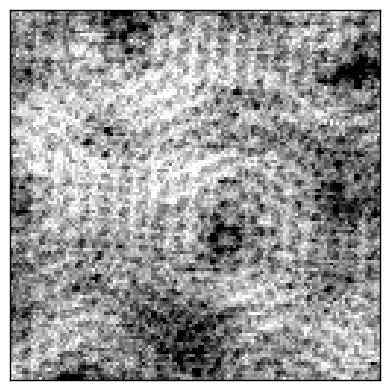

In [5]:
bf_obj = direct_ptycho.vbf_stack.sum(0).numpy()
em.visualization.show_2d(bf_obj);

## Direct Ptychography Optimization

In [6]:
direct_ptycho=direct_ptycho.optimize_hyperparameters(
    aberration_coefs={
        "C10":OptimizationParameter(50,150),
        "C12":OptimizationParameter(0, 50),
        "phi12":OptimizationParameter(-np.pi/2, np.pi/2)
    },
    rotation_angle=OptimizationParameter(np.deg2rad(170),np.deg2rad(190)), 
    deconvolution_kernel='parallax',
    n_trials=150,
    max_batch_size=128,
)

Best trial: 79. Best value: 1.57135e-08: 100%|████████████████████████████████████████████████| 150/150 [00:22<00:00,  6.79it/s]


Optimized state:

 HyperparameterState(
  initial_aberrations={'C10': 93.0},
  initial_rotation_angle=np.float64(3.193952531149623),
  optimized_aberrations={'C10': 106.50457463443888, 'C12': 8.100845980699516, 'phi12': -0.6429325734569429},
  optimized_rotation_angle=3.1090773308701136,
)


In [20]:
par_obj = direct_ptycho.reconstruct(
    deconvolution_kernel='parallax', 
    max_batch_size=128,
    upsampling_factor=1,
    verbose=False,
).obj

ssb_obj = direct_ptycho.reconstruct(
    deconvolution_kernel='ssb', 
    max_batch_size=128,
    upsampling_factor=1,
    verbose=False,
).obj


icom_obj = direct_ptycho.reconstruct(
    deconvolution_kernel='icom',
    max_batch_size=128,
    q_highpass=0.2,
    verbose=False,
).obj


In [27]:
from dataclasses import replace

def fft(ar): 
    n0 = ar.shape
    w0 = np.hanning(n0[1]) * np.hanning(n0[0])[:, None]
    ar_fft = np.abs(np.fft.fftshift(np.fft.fft2(w0 * ar.copy())))
    return ar_fft

norm = em.visualization.NormalizationConfig(
    # interval_type="manual",
    upper_quantile=0.995,
    lower_quantile = 0
)

crop = 75
pad = np.abs(par_obj.shape[0] - icom_obj.shape[0] )//2

scalebar_real = em.visualization.ScalebarConfig(
    sampling=dc.sampling[0],
    units=r'$\AA$',
)

scalebar_reciprocal = em.visualization.ScalebarConfig(
    sampling=np.fft.fftfreq(ssb_obj.shape[0],dc.sampling[0])[1],
    units=r'$\AA^{-1}$',
    length=1,
)

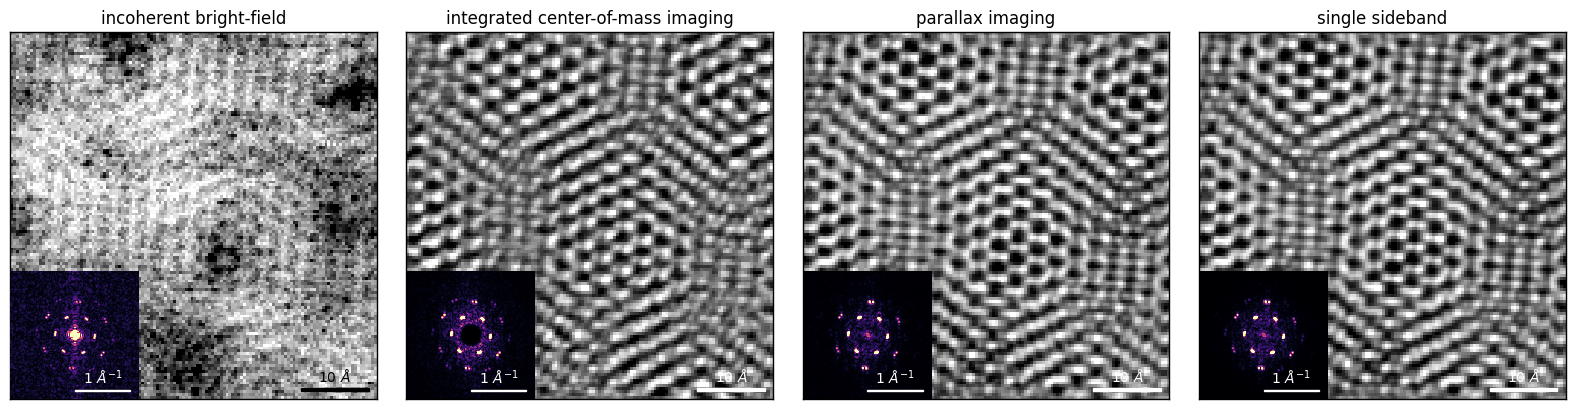

In [28]:
fig, ax = em.visualization.show_2d(
    [
        bf_obj,
        icom_obj,
        par_obj,
        ssb_obj,
    ],
    cmap=["gray"],
    title=["incoherent bright-field","integrated center-of-mass imaging","parallax imaging","single sideband"],
    axsize=(4,4),
    returnfig = True,
    scalebar=[replace(scalebar_real,color='black'),scalebar_real,scalebar_real,scalebar_real],
);

ax_inset = ax[0].inset_axes([0, 0, 0.35, 0.35])
ax_inset.axis('off')
em.visualization.show_2d(
    fft(bf_obj),
    figax = (fig, ax_inset),
    norm = norm,
    scalebar=scalebar_reciprocal,
    cmap = "magma"
);

ax_inset = ax[1].inset_axes([0, 0, 0.35, 0.35])
ax_inset.axis('off')
em.visualization.show_2d(
    fft(icom_obj),
    figax = (fig, ax_inset),
    norm = norm,
    scalebar=scalebar_reciprocal,
    cmap = "magma"
);

ax_inset = ax[2].inset_axes([0, 0, 0.35, 0.35])
ax_inset.axis('off')
em.visualization.show_2d(
    fft(par_obj),
    figax = (fig, ax_inset),
    norm = norm,
    scalebar=scalebar_reciprocal,
    cmap = "magma"
);

ax_inset = ax[3].inset_axes([0, 0, 0.35, 0.35])
ax_inset.axis('off')
em.visualization.show_2d(
    fft(ssb_obj),
    figax = (fig, ax_inset),
    norm = norm,
    scalebar=scalebar_reciprocal,
    cmap = "magma"
);

plt.savefig('mos2_inset.pdf', bbox_inches = "tight")